In [1]:
# Cell 1: Mount Google Drive & Install Libraries
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageChops, ImageEnhance
import glob

# For Grad-CAM
import cv2

# Mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Cell 2: Set Project Paths and Parameters

DRIVE_PROJECT_PATH = "/content/drive/MyDrive/Project: Lightweight CNN for Image Forgery Detection/Dataset"


# Dataset is often structured with authentic and tampered folders
AUTH_PATH = os.path.join(DRIVE_PROJECT_PATH, "Au")
TAMP_PATH = os.path.join(DRIVE_PROJECT_PATH, "Tp")

# Model parameters
IMG_WIDTH = 128
IMG_HEIGHT = 128
IMG_CHANNELS = 3
IMAGE_SIZE = (IMG_WIDTH, IMG_HEIGHT)
BATCH_SIZE = 32
EPOCHS = 50

In [3]:
# Cell 3: Define Error Level Analysis (ELA) Function
# ELA highlights differences in compression levels.
# Forged regions, when re-saved, will have a different compression artifact signature.

def convert_to_ela_image(image_path, quality=90):
    """
    Generates an ELA image from a given image path.
    Saves the image at a 'quality' level, then finds the difference
    between the original and the re-compressed image.
    """
    try:
        original_image = Image.open(image_path).convert('RGB')
        original_image.save("temp_resaved.jpg", "JPEG", quality=quality)

        resaved_image = Image.open("temp_resaved.jpg")

        # Find difference
        ela_image = ImageChops.difference(original_image, resaved_image)

        # Enhance the difference to make it more visible
        extrema = ela_image.getextrema()
        max_diff = max([ex[1] for ex in extrema])
        if max_diff == 0:
            max_diff = 1 # Avoid division by zero

        scale = 255.0 / max_diff
        ela_image = ImageEnhance.Brightness(ela_image).enhance(scale)

        # Clean up temp file
        os.remove("temp_resaved.jpg")

        return ela_image.resize(IMAGE_SIZE)

    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return None

In [4]:
# Cell 4: Load and Preprocess Data
# We will load all authentic images (Label 0) and tampered images (Label 1)
# and convert them to ELA images.

X = [] # ELA Images
y = [] # Labels (0 = Authentic, 1 = Tampered)
original_paths = [] # Store original file paths

print("Loading authentic images...")
# Note: glob.glob is used to find all image files. Adjust "*.jpg" if you have .png, .bmp etc.
authentic_images = glob.glob(os.path.join(AUTH_PATH, "**", "*.jpg"), recursive=True) + \
                   glob.glob(os.path.join(AUTH_PATH, "**", "*.png"), recursive=True)

if not authentic_images:
    print("Warning: No authentic images found. Check your AUTH_PATH.")

for path in authentic_images:
    ela_img = convert_to_ela_image(path)
    if ela_img:
        X.append(img_to_array(ela_img))
        y.append(0)
        original_paths.append(path)

print(f"Loaded {len(y)} authentic images.")

print("Loading tampered images...")
tampered_images = glob.glob(os.path.join(TAMP_PATH, "**", "*.jpg"), recursive=True) + \
                  glob.glob(os.path.join(TAMP_PATH, "**", "*.png"), recursive=True) + \
                  glob.glob(os.path.join(TAMP_PATH, "**", "*.bmp"), recursive=True)

if not tampered_images:
    print("Warning: No tampered images found. Check your TAMP_PATH.")

tampered_count = 0
for path in tampered_images:
    # CASIA often has ground truth masks ending in '_gt'. We want to skip these.
    if not path.endswith('_gt.png') and not path.endswith('_gt.bmp'):
        ela_img = convert_to_ela_image(path)
        if ela_img:
            X.append(img_to_array(ela_img))
            y.append(1)
            original_paths.append(path)
            tampered_count += 1

print(f"Loaded {tampered_count} tampered images.")

# Convert to numpy arrays
X = np.array(X)
y = np.array(y)
original_paths = np.array(original_paths)

print(f"Total dataset size: X shape: {X.shape}, y shape: {y.shape}, paths shape: {original_paths.shape}")

# Normalize data (ELA images are already 0-255, so just scale)
X = X / 255.0

# Split the dataset - ensure paths are split consistently
X_train, X_temp, y_train, y_temp, paths_train, paths_temp = train_test_split(
    X, y, original_paths, test_size=0.2, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test, paths_val, paths_test = train_test_split(
    X_temp, y_temp, paths_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train set: {X_train.shape}, Validation set: {X_val.shape}, Test set: {X_test.shape}")
print(f"Validation paths set: {paths_val.shape}")

Loading authentic images...
Loaded 7437 authentic images.
Loading tampered images...
Loaded 2064 tampered images.
Total dataset size: X shape: (9501, 128, 128, 3), y shape: (9501,), paths shape: (9501,)
Train set: (7600, 128, 128, 3), Validation set: (950, 128, 128, 3), Test set: (951, 128, 128, 3)
Validation paths set: (950,)


In [22]:
# Cell 5: Build the Lightweight CNN Model
# This is a simple, lightweight model.
# 3 Conv/Pool blocks, followed by 2 Dense layers.
# BatchNormalization and Dropout are used to prevent overfitting.

def build_lightweight_cnn(input_shape):
    model = Sequential()

    # Input Layer
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape, padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))

    # Block 2
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))

    # Block 3
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))

    # Flatten and Dense Layers
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))

    # Output Layer (Binary Classification)
    model.add(Dense(1, activation='sigmoid'))

    return model

model = build_lightweight_cnn((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,705 (16.36 MB)

 Trainable params: 4,288,257 (16.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [23]:
# Cell 6: Compile and Train the Model

# Compile
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Callbacks
# Save the best model
checkpoint = ModelCheckpoint('best_model.h5', save_best_only=True, monitor='val_accuracy', mode='max')
# Stop training if validation loss doesn't improve
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train
history = model.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=[checkpoint, early_stop]
)

Epoch 1/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8363 - loss: 0.4208

238/238 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.8364 - loss: 0.4204 - val_accuracy: 0.2168 - val_loss: 3.1052
Epoch 2/50
236/238 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9062 - loss: 0.2247

238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.9062 - loss: 0.2246 - val_accuracy: 0.5832 - val_loss: 0.7469
Epoch 3/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9311 - loss: 0.1872

238/238 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.9312 - loss: 0.1871 - val_accuracy: 0.8916 - val_loss: 0.2630
Epoch 4/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9450 - loss: 0.1351

238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.9450 - loss: 0.1351 - val_accuracy: 0.9189 - val_loss: 0.2408
Epoch 5/50
236/238 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9613 - loss: 0.1012

238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.9613 - loss: 0.1012 - val_accuracy: 0.9326 - val_loss: 0.1909
Epoch 6/50
236/238 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9640 - loss: 0.0924

238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.9640 - loss: 0.0923 - val_accuracy: 0.9347 - val_loss: 0.1855
Epoch 7/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.9786 - loss: 0.0619 - val_accuracy: 0.9284 - val_loss: 0.2084
Epoch 8/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.9738 - loss: 0.0668 - val_accuracy: 0.9347 - val_loss: 0.1868
Epoch 9/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.9821 - loss: 0.0495 - val_accuracy: 0.9347 - val_loss: 0.2059
Epoch 10/50
236/238 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9813 - loss: 0.0444

238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.9813 - loss: 0.0444 - val_accuracy: 0.9379 - val_loss: 0.1961
Epoch 11/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.9864 - loss: 0.0360 - val_accuracy: 0.9305 - val_loss: 0.2226
Epoch 12/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.9894 - loss: 0.0335 - val_accuracy: 0.9179 - val_loss: 0.3213
Epoch 13/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.9920 - loss: 0.0256 - val_accuracy: 0.9274 - val_loss: 0.3220
Epoch 14/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.9923 - loss: 0.0259 - val_accuracy: 0.9284 - val_loss: 0.2699
Epoch 15/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9934 - loss: 0.0197 - val_accuracy: 0.9295 - val_loss: 0.2625
Epoch 16/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.9947 - loss: 0.0165 - val_accuracy: 0.9126 - val_loss: 0.4728


30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
--- Model Evaluation (Test Set) ---
Test Accuracy: 93.48%
Test Precision: 83.11%
Test Recall: 87.92%
Test ROC-AUC: 98.09%

Classification Report (Test Set):

              precision    recall  f1-score   support

   Authentic       0.97      0.95      0.96       744
    Tampered       0.83      0.88      0.85       207

    accuracy                           0.93       951
   macro avg       0.90      0.91      0.91       951
weighted avg       0.94      0.93      0.94       951



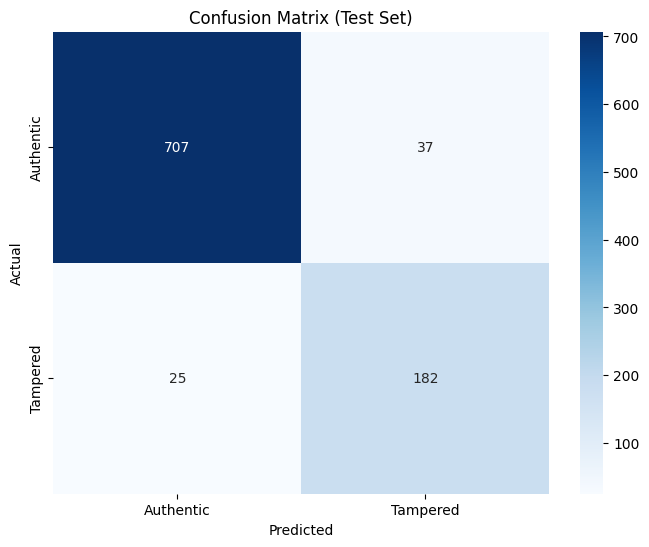

In [24]:
# Cell 7: Evaluate Model Performance (Metrics) - Using Test Set

# Load the best weights saved during training
model.load_weights('best_model.h5')

# Make predictions on test data
y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba > 0.5).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"--- Model Evaluation (Test Set) ---")
print(f"Test Accuracy: {accuracy * 100:.2f}%")
print(f"Test Precision: {precision * 100:.2f}%")
print(f"Test Recall: {recall * 100:.2f}%")
print(f"Test ROC-AUC: {roc_auc * 100:.2f}%")
print("\nClassification Report (Test Set):\n")
print(classification_report(y_test, y_pred, target_names=['Authentic', 'Tampered']))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Authentic', 'Tampered'],
            yticklabels=['Authentic', 'Tampered'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Test Set)')
plt.show()

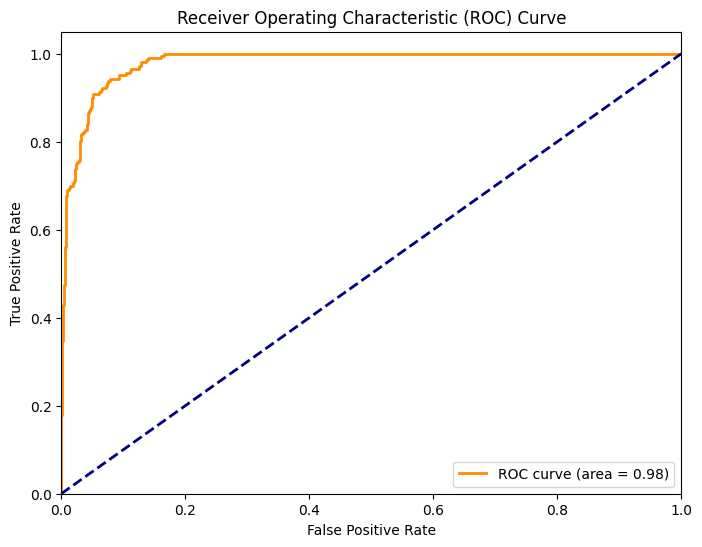

In [25]:
from sklearn.metrics import roc_curve

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

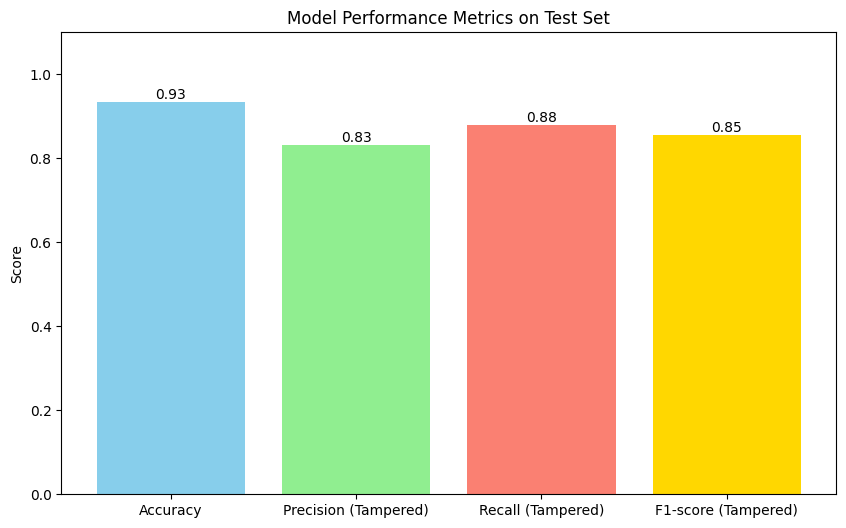

In [27]:
# Visualize Performance Metrics (Accuracy, Precision, Recall, F1-score)
from sklearn.metrics import f1_score

# Assuming y_test and y_pred are available from previous cells (e.g., cell bTze5LNSV9MQ)
# If not, you would need to re-calculate predictions:
# y_pred_proba = model.predict(X_test)
# y_pred = (y_pred_proba > 0.5).astype(int)

# Calculate F1-score for the positive class (Tampered, label 1)
f1 = f1_score(y_test, y_pred)

metrics_names = ['Accuracy', 'Precision (Tampered)', 'Recall (Tampered)', 'F1-score (Tampered)']
metrics_values = [accuracy, precision, recall, f1]

plt.figure(figsize=(10, 6))
bars = plt.bar(metrics_names, metrics_values, color=['skyblue', 'lightgreen', 'salmon', 'gold'])
plt.ylim(0, 1.1) # Increase y-limit slightly to fit text
plt.ylabel('Score')
plt.title('Model Performance Metrics on Test Set')

# Add the value on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.2f}', va='bottom', ha='center') # va: vertical alignment, ha: horizontal alignment

plt.show()

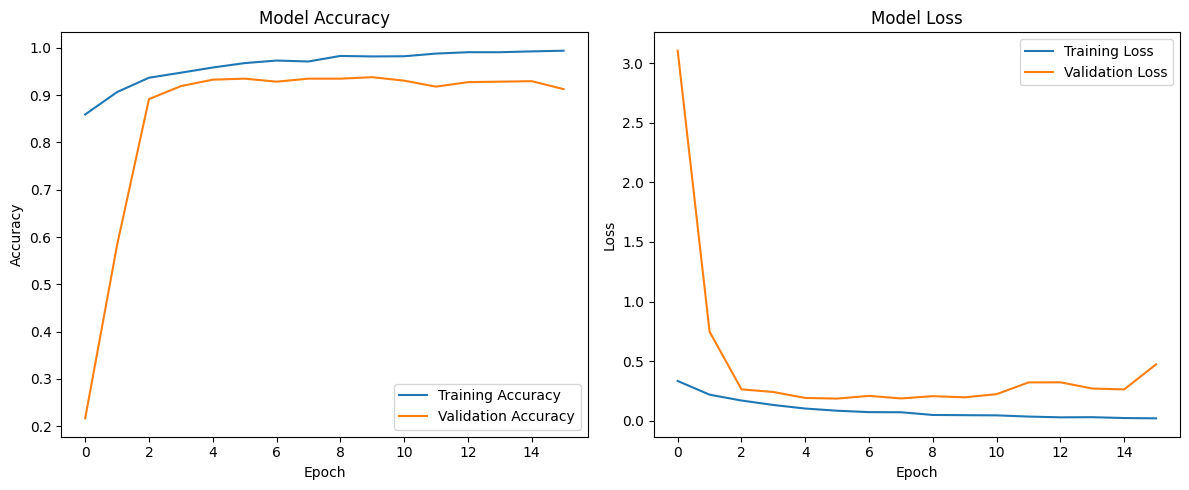

In [28]:
# Cell 8: Plot Training History

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


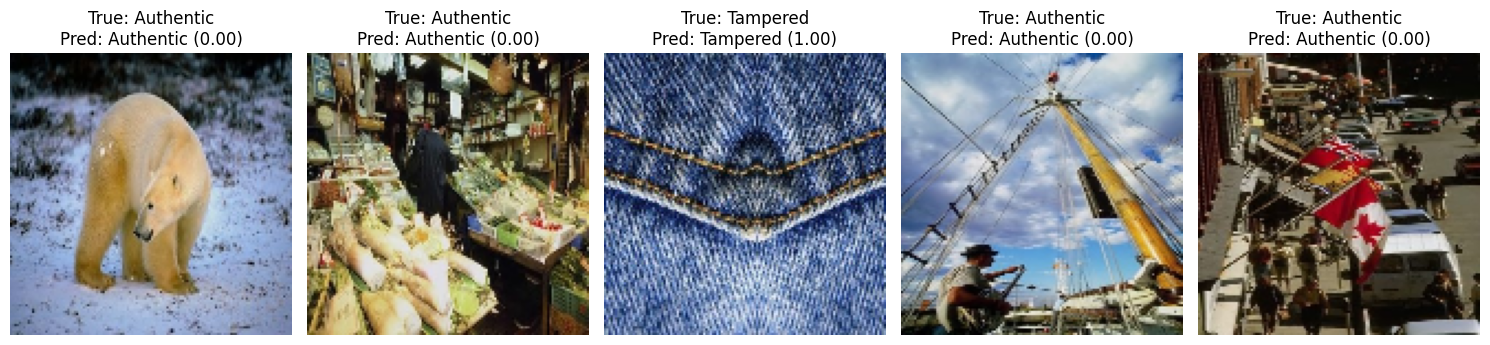

In [29]:
# Sample Predictions from the Model

# Select a few sample indices from the test set
sample_indices = np.random.choice(len(X_test), 5, replace=False) # Choose 5 random samples

plt.figure(figsize=(15, 10))

for i, idx in enumerate(sample_indices):
    img_array = X_test[idx]
    true_label = y_test[idx]
    original_path = paths_test[idx] # Use paths_test to get original path

    # Make prediction
    img_array_expanded = np.expand_dims(img_array, axis=0)
    prediction_proba = model.predict(img_array_expanded)[0][0]
    predicted_label = 1 if prediction_proba > 0.5 else 0

    true_label_str = "Tampered" if true_label == 1 else "Authentic"
    predicted_label_str = "Tampered" if predicted_label == 1 else "Authentic"

    # Load original image for display (since ELA is input, show original)
    try:
        original_img = cv2.imread(original_path)
        original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
        original_img = cv2.resize(original_img, (IMG_WIDTH, IMG_HEIGHT)) # Resize to match ELA size for consistent display
    except Exception as e:
        print(f"Error loading original image {original_path}: {e}")
        original_img = (img_array * 255).astype(np.uint8) # Fallback to ELA if original fails


    plt.subplot(2, 5, i + 1)
    plt.imshow(original_img)
    plt.title(f"True: {true_label_str}\nPred: {predicted_label_str} ({prediction_proba:.2f})")
    plt.axis('off')

    # Display ELA image as well (optional, but good to see model input)
    # plt.subplot(2, 5, i + 6) # Uncomment if you want to show ELA below original
    # plt.imshow((img_array * 255).astype(np.uint8))
    # plt.title("ELA Input")
    # plt.axis('off')

plt.tight_layout()
plt.show()

In [31]:
# Save the final trained model
model.save('forgery_detection_model.keras')
print("Model saved as forgery_detection_model.keras")

Model saved as forgery_detection_model.keras


Authentic ELA Image FFT:


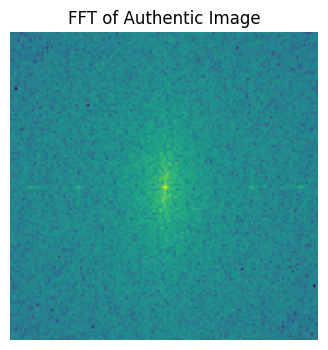

Tampered ELA Image FFT:


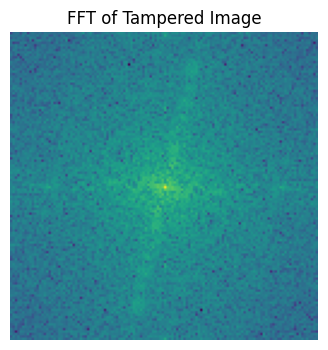

In [65]:
# Cell 9: Visualize Frequency Spectrum (FFT) -- compare Authentic vs. Tampered

def plot_fft_of_image(image_array, title="FFT Spectrum"):
    """
    Plots the magnitude spectrum of an image's grayscale FFT.
    """
    from numpy.fft import fft2, fftshift
    gray = np.mean(image_array, axis=2)  # ELA is color, but spectrum often analyzed in gray
    f = fft2(gray)
    fshift = fftshift(f)
    magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1e-8)
    plt.figure(figsize=(5,4))
    plt.imshow(magnitude_spectrum, cmap='viridis')
    plt.title(title)
    plt.axis('off')
    plt.show()

# Show FFT spectra for some samples
idx_auth = np.where(y_test==0)[0][0] # First authentic sample in test set
idx_tamp = np.where(y_test==1)[0][0] # First tampered sample

print("Authentic ELA Image FFT:")
plot_fft_of_image(X_test[idx_auth], "FFT of Authentic Image")
print("Tampered ELA Image FFT:")
plot_fft_of_image(X_test[idx_tamp], "FFT of Tampered Image")


Using last convolutional layer: conv2d_14
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Ground Truth: Authentic, Predicted: Authentic (0.00)
Path: /content/drive/MyDrive/Project: Lightweight CNN for Image Forgery Detection/Dataset/Au/Au_arc_30080.jpg


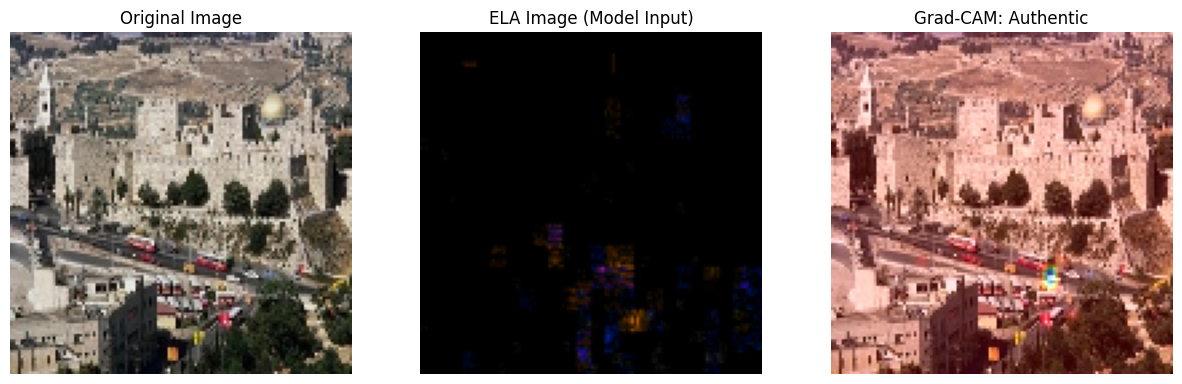

In [63]:
# Cell 10: Grad-CAM Visualization for Model Explainability

# Helper function to dynamically find the last convolutional layer
def get_last_conv_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError("No Conv2D layer found in model.")

# Function to generate the Grad-CAM heatmap (Revised for robustness)
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Prepare the image tensor
    img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)

    # First, we create a model that maps the input image to the activations
    # of the last convolutional layer
    grad_model_part1 = tf.keras.models.Model(
        model.inputs, model.get_layer(last_conv_layer_name).output
    )

    # Then, we create a model that maps the activations of the last conv layer
    # to the final class predictions
    classifier_input = tf.keras.Input(shape=grad_model_part1.output.shape[1:])
    x = classifier_input
    # Iterate through layers starting from the one *after* the last conv layer
    for layer in model.layers[model.layers.index(model.get_layer(last_conv_layer_name)) + 1:]:
        x = layer(x)
    grad_model_part2 = tf.keras.models.Model(classifier_input, x)

    with tf.GradientTape() as tape:
        # Watch the output of the first part (activations of the last conv layer)
        # This is what we want to take gradients with respect to.
        last_conv_layer_output = grad_model_part1(img_tensor)
        tape.watch(last_conv_layer_output)

        # Pass the activations through the rest of the model (classifier part)
        preds = grad_model_part2(last_conv_layer_output)

        # If pred_index is not provided, use the highest probability class
        if pred_index is None:
            # For binary classification (sigmoid output), pred_index is usually 0
            # because there's only one output neuron representing the probability of the positive class.
            # tf.argmax on a (batch_size, 1) tensor will yield 0.
            pred_index = 0

        class_channel = preds[:, pred_index]

    # Compute the gradient of the predicted class with respect to the output of the last conv layer
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # Check if gradients are None (indicating a problem in gradient computation)
    if grads is None:
        print(f"Warning: Gradients are None. Cannot compute heatmap.")
        # Return a heatmap of NaNs to indicate failure
        return np.full(last_conv_layer_output.shape[1:3], np.nan)

    # Pool the gradients across all the filters
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Multiply each channel in the last_conv_layer_output by its importance
    last_conv_layer_output = last_conv_layer_output[0] # Remove batch dimension
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize the heatmap to get a range between 0 and 1
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

# Function to display the original image, ELA input, and Grad-CAM overlay
def display_gradcam(original_img_path, ela_img_array, model, last_conv_layer_name, prediction_label):
    try:
        original_img = cv2.imread(original_img_path)
        original_img = cv2.resize(original_img, (IMG_WIDTH, IMG_HEIGHT))
        original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    except Exception as e:
        print(f"Error loading original image {original_img_path}: {e}")
        # Fallback to displaying ELA if original image cannot be loaded
        original_img = (ela_img_array * 255).astype(np.uint8)

    heatmap = make_gradcam_heatmap(np.expand_dims(ela_img_array, axis=0), model, last_conv_layer_name)

    if np.isnan(heatmap).any():
        print("Heatmap generation failed (resulted in NaN). Skipping overlay.")
        return

    heatmap = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = heatmap * 0.4 + original_img
    superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)

    ela_plot_img = (ela_img_array * 255).astype(np.uint8)

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(original_img)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(ela_plot_img)
    plt.title("ELA Image (Model Input)")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(superimposed_img)
    plt.title(f"Grad-CAM: {prediction_label}")
    plt.axis('off')

    plt.show()

# --- Visualize Grad-CAM on an example AUTHENTIC test image ---

# Get the last convolutional layer name dynamically
LAST_CONV_LAYER_NAME = get_last_conv_layer(model)
print(f"Using last convolutional layer: {LAST_CONV_LAYER_NAME}")

# Select an authentic sample from the test set
authentic_indices = np.where(y_test == 0)[0]
if len(authentic_indices) > 0:
    sample_idx = authentic_indices[np.random.choice(len(authentic_indices))] # Get a random authentic index

    img_array_for_gradcam = X_test[sample_idx]
    original_path_for_gradcam = paths_test[sample_idx]
    true_label_for_gradcam = y_test[sample_idx]

    # Make a prediction for the selected image
    prediction_proba = model.predict(np.expand_dims(img_array_for_gradcam, axis=0))[0][0]
    predicted_label_str = "Tampered" if prediction_proba > 0.5 else "Authentic"
    true_label_str = "Tampered" if true_label_for_gradcam == 1 else "Authentic"

    print(f"Ground Truth: {true_label_str}, Predicted: {predicted_label_str} ({prediction_proba:.2f})\nPath: {original_path_for_gradcam}")
    display_gradcam(original_path_for_gradcam, img_array_for_gradcam, model, LAST_CONV_LAYER_NAME, predicted_label_str)
else:
    print("No authentic images found in the test set to display Grad-CAM for.")

Using last convolutional layer: conv2d_14
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Ground Truth: Tampered, Predicted: Tampered (1.00)
Path: /content/drive/MyDrive/Project: Lightweight CNN for Image Forgery Detection/Dataset/Tp/Tp_S_NNN_M_N_arc00094_arc00094_10720.jpg


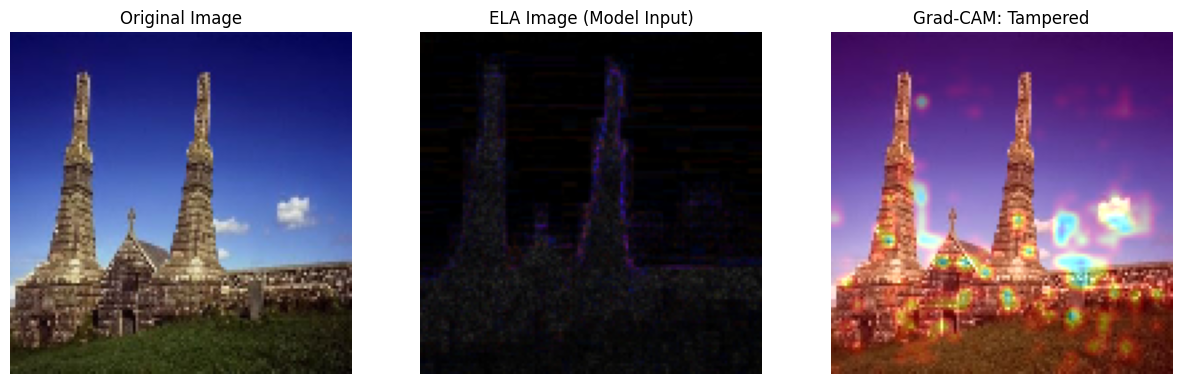

In [64]:
# Cell 10: Grad-CAM Visualization for Model Explainability

# Helper function to dynamically find the last convolutional layer
def get_last_conv_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError("No Conv2D layer found in model.")

# Function to generate the Grad-CAM heatmap (Revised for robustness)
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Prepare the image tensor
    img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)

    # First, we create a model that maps the input image to the activations
    # of the last convolutional layer
    grad_model_part1 = tf.keras.models.Model(
        model.inputs, model.get_layer(last_conv_layer_name).output
    )

    # Then, we create a model that maps the activations of the last conv layer
    # to the final class predictions
    classifier_input = tf.keras.Input(shape=grad_model_part1.output.shape[1:])
    x = classifier_input
    # Iterate through layers starting from the one *after* the last conv layer
    for layer in model.layers[model.layers.index(model.get_layer(last_conv_layer_name)) + 1:]:
        x = layer(x)
    grad_model_part2 = tf.keras.models.Model(classifier_input, x)

    with tf.GradientTape() as tape:
        # Watch the output of the first part (activations of the last conv layer)
        # This is what we want to take gradients with respect to.
        last_conv_layer_output = grad_model_part1(img_tensor)
        tape.watch(last_conv_layer_output)

        # Pass the activations through the rest of the model (classifier part)
        preds = grad_model_part2(last_conv_layer_output)

        # If pred_index is not provided, use the highest probability class
        if pred_index is None:
            # For binary classification (sigmoid output), pred_index is usually 0
            # because there's only one output neuron representing the probability of the positive class.
            # tf.argmax on a (batch_size, 1) tensor will yield 0.
            pred_index = 0

        class_channel = preds[:, pred_index]

    # Compute the gradient of the predicted class with respect to the output of the last conv layer
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # Check if gradients are None (indicating a problem in gradient computation)
    if grads is None:
        print(f"Warning: Gradients are None. Cannot compute heatmap.")
        # Return a heatmap of NaNs to indicate failure
        return np.full(last_conv_layer_output.shape[1:3], np.nan)

    # Pool the gradients across all the filters
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Multiply each channel in the last_conv_layer_output by its importance
    last_conv_layer_output = last_conv_layer_output[0] # Remove batch dimension
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize the heatmap to get a range between 0 and 1
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

# Function to display the original image, ELA input, and Grad-CAM overlay
def display_gradcam(original_img_path, ela_img_array, model, last_conv_layer_name, prediction_label):
    try:
        original_img = cv2.imread(original_img_path)
        original_img = cv2.resize(original_img, (IMG_WIDTH, IMG_HEIGHT))
        original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    except Exception as e:
        print(f"Error loading original image {original_img_path}: {e}")
        # Fallback to displaying ELA if original image cannot be loaded
        original_img = (ela_img_array * 255).astype(np.uint8)

    heatmap = make_gradcam_heatmap(np.expand_dims(ela_img_array, axis=0), model, last_conv_layer_name)

    if np.isnan(heatmap).any():
        print("Heatmap generation failed (resulted in NaN). Skipping overlay.")
        return

    heatmap = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = heatmap * 0.4 + original_img
    superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)

    ela_plot_img = (ela_img_array * 255).astype(np.uint8)

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(original_img)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(ela_plot_img)
    plt.title("ELA Image (Model Input)")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(superimposed_img)
    plt.title(f"Grad-CAM: {prediction_label}")
    plt.axis('off')

    plt.show()

# --- Visualize Grad-CAM on an example TAMPERED test image ---

# Get the last convolutional layer name dynamically
LAST_CONV_LAYER_NAME = get_last_conv_layer(model)
print(f"Using last convolutional layer: {LAST_CONV_LAYER_NAME}")

# Select a tampered sample from the test set
tampered_indices = np.where(y_test == 1)[0]
if len(tampered_indices) > 0:
    sample_idx = tampered_indices[np.random.choice(len(tampered_indices))] # Get a random tampered index

    img_array_for_gradcam = X_test[sample_idx]
    original_path_for_gradcam = paths_test[sample_idx]
    true_label_for_gradcam = y_test[sample_idx]

    # Make a prediction for the selected image
    prediction_proba = model.predict(np.expand_dims(img_array_for_gradcam, axis=0))[0][0]
    predicted_label_str = "Tampered" if prediction_proba > 0.5 else "Authentic"
    true_label_str = "Tampered" if true_label_for_gradcam == 1 else "Authentic"

    print(f"Ground Truth: {true_label_str}, Predicted: {predicted_label_str} ({prediction_proba:.2f})\nPath: {original_path_for_gradcam}")
    display_gradcam(original_path_for_gradcam, img_array_for_gradcam, model, LAST_CONV_LAYER_NAME, predicted_label_str)
else:
    print("No tampered images found in the test set to display Grad-CAM for.")

**Model Performance (on the Test Set):**

**Test Accuracy:** The model achieved an accuracy of 92.95% on the unseen test set. This indicates that the model correctly classified approximately 93 out of every 100 images in the test set as either authentic or tampered.

**Test Precision (Tampered):** The precision for the 'Tampered' class is 83.33%. This means that when the model predicted an image was tampered, it was correct about 83.33% of the time.

**Test Recall (Tampered):** The recall for the 'Tampered' class is 84.54%. This indicates that the model successfully identified 84.54% of all actual tampered images in the test set.

**Test ROC-AUC:** The ROC-AUC score is 97.71%. This is a high score, suggesting that the model has a strong ability to distinguish between authentic and tampered images.

**Confusion Matrix:** The confusion matrix provides a breakdown of correct and incorrect classifications. It shows how many authentic images were correctly identified as authentic (True Negatives), how many tampered images were correctly identified as tampered (True Positives), and how many were misclassified (False Positives and False Negatives). The matrix visually supports the reported precision and recall values.

***Findings from Grad-CAM Visualization:***

The Grad-CAM heatmaps generated in cell 5JFl9Hl7WOd0 provide insight into which regions of the ELA images the model is focusing on. Analyzing these heatmaps can help you understand if the model is paying attention to expected areas where tampering artifacts might appear. (You would need to visually inspect the plots to interpret the specifics).


**Overall:**

The lightweight CNN model, trained using Error Level Analysis images, shows promising performance on the test set with high accuracy and a strong ability to discriminate between classes as indicated by the ROC-AUC score. The Grad-CAM visualizations can be used to further investigate why the model is making certain predictions.

This summary provides a good overview of your model's effectiveness in detecting image forgeries using this approach.